In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

df = pd.read_csv(r"C:\Users\hp\Downloads\archive (6)\creditcard.csv")

print("Shape:", df.shape)
df.info()

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

=== CLASS DISTRIBUTION ===
Class
0    284315
1       492
Name: count, dtype: int64

Class
0   99.83
1    0.17
Name: proportion, dtype: float64


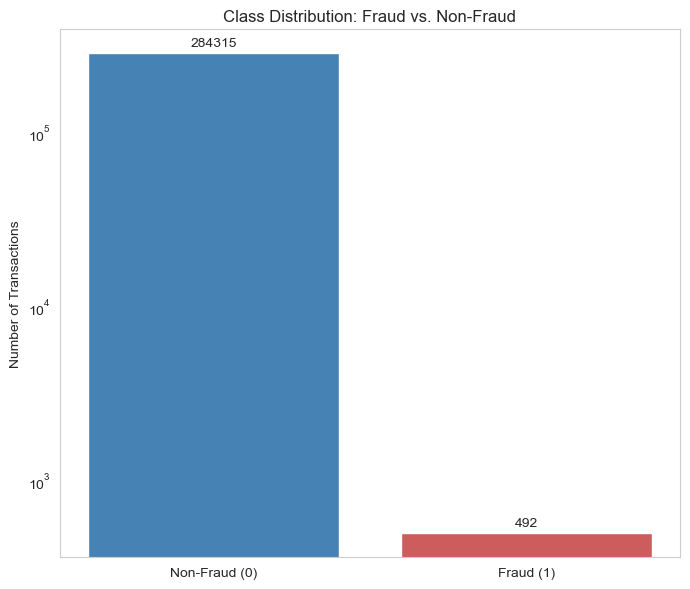

In [3]:
# Class imbalance analysis
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(class_counts)
print()
print(class_pct.round(4))

plt.figure(figsize=(7,6))
bars = plt.bar(['Non-Fraud (0)', 'Fraud (1)'], class_counts.values, color=['steelblue', 'indianred'])
plt.bar_label(bars, padding=3)
plt.title("Class Distribution: Fraud vs. Non-Fraud")
plt.ylabel("Number of Transactions")
plt.yscale('log')  # log scale is necessary here — fraud count would be invisible on a linear scale
plt.grid(False)
plt.tight_layout()
plt.show()

Class Imbalance: Of 284,807 total transactions, only 492 (0.17%) are labeled fraudulent — a severe class imbalance of roughly 1 fraud case per 578 legitimate transactions. A model that predicted "not fraud" for every single transaction would achieve 99.83% accuracy while catching zero fraud cases — a completely useless model by any practical standard, despite the seemingly excellent accuracy score. This is the core motivation for this entire project: standard accuracy cannot be trusted as an evaluation metric here, and specialized techniques (SMOTE, class weighting) and metrics (precision, recall, F1, AUC-ROC) are required instead.

In [4]:
#EDA — Transaction amount distribution, fraud vs. non-fraud

fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

print("=== Amount statistics: Fraud ===")
print(fraud['Amount'].describe())
print("\n=== Amount statistics: Non-Fraud ===")
print(non_fraud['Amount'].describe())

=== Amount statistics: Fraud ===
count    492.00
mean     122.21
std      256.68
min        0.00
25%        1.00
50%        9.25
75%      105.89
max     2125.87
Name: Amount, dtype: float64

=== Amount statistics: Non-Fraud ===
count   284315.00
mean        88.29
std        250.11
min          0.00
25%          5.65
50%         22.00
75%         77.05
max      25691.16
Name: Amount, dtype: float64


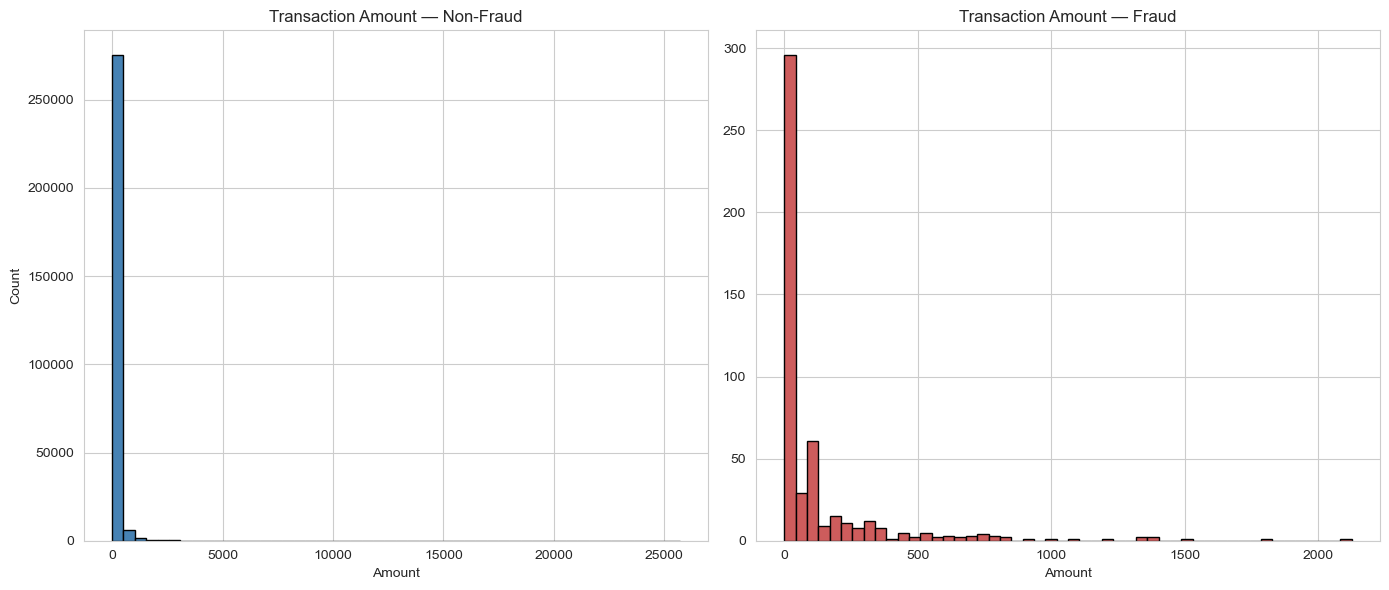

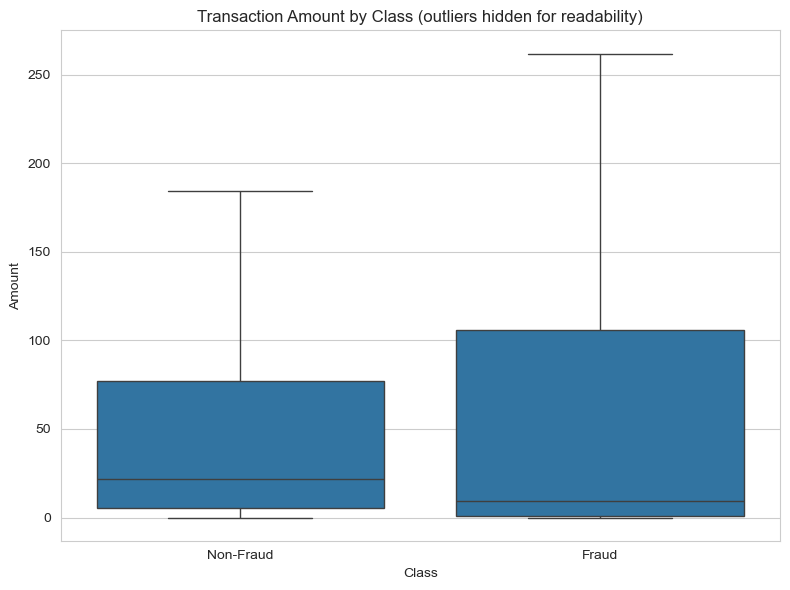

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(non_fraud['Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title("Transaction Amount — Non-Fraud")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count")

axes[1].hist(fraud['Amount'], bins=50, color='indianred', edgecolor='black')
axes[1].set_title("Transaction Amount — Fraud")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

# Boxplot comparison — capped at a reasonable range since both distributions are heavily right-skewed
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Class', y='Amount', showfliers=False)
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.title("Transaction Amount by Class (outliers hidden for readability)")
plt.tight_layout()
plt.show()

Transaction Amount — Fraud vs. Non-Fraud: Fraudulent transactions have a noticeably higher average amount ($122.21) than legitimate ones ($88.29), but this is driven by the mean, not the median — the median fraud amount ($9.25) is actually lower than the median legitimate amount ($22.00). This tells us fraud amounts are more polarized: there's a cluster of very small-value fraud (likely "testing" transactions criminals use to verify a stolen card works before attempting a larger purchase), alongside occasional larger fraudulent charges pulling the mean upward. Legitimate transactions, meanwhile, are more evenly distributed. Non-fraud transactions also have a much higher maximum ($25,691 vs. $2,126 for fraud), meaning very large transactions are essentially never fraudulent in this dataset — worth treating as a potential signal in feature importance later.

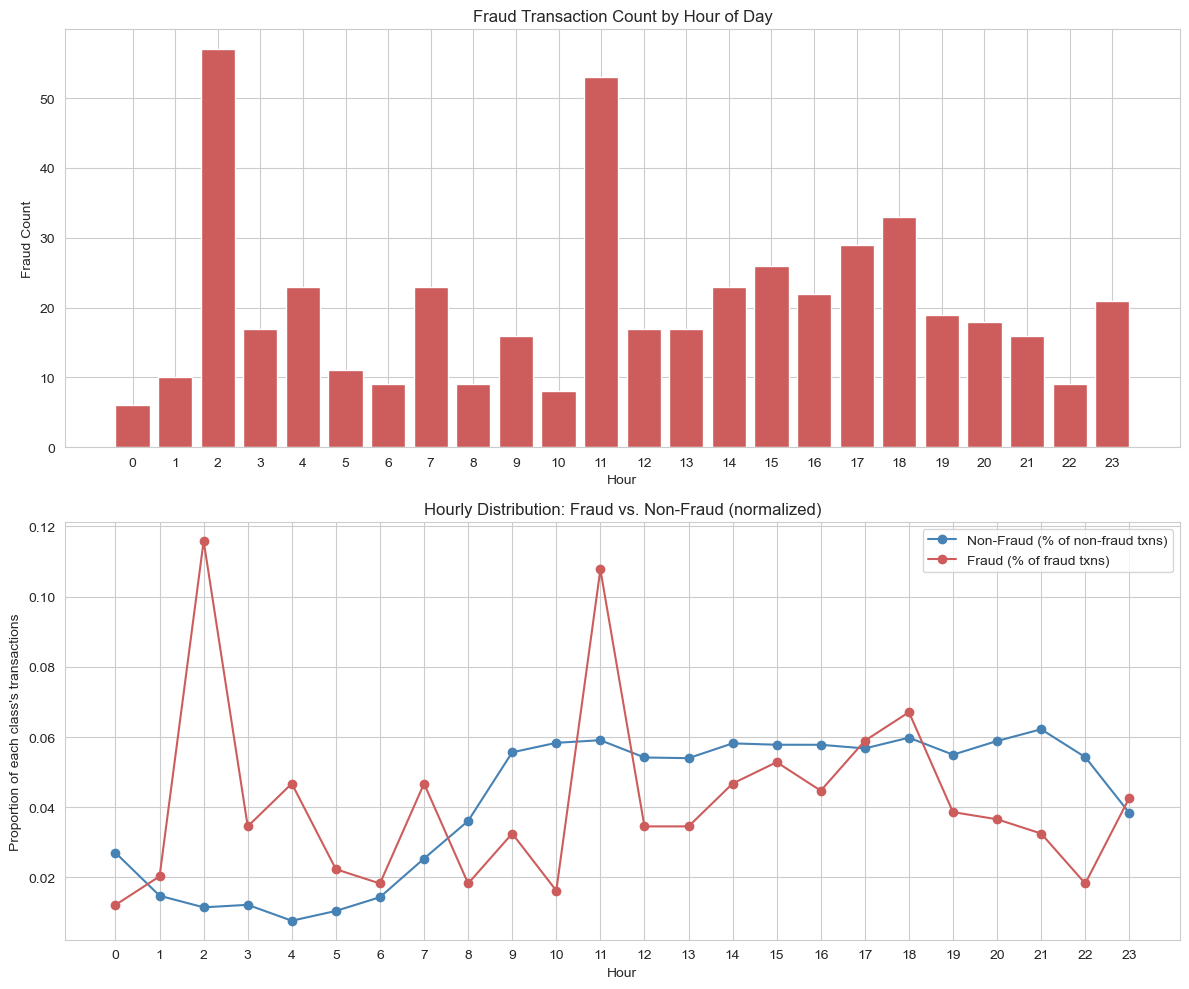

In [6]:
# 'Time' is seconds elapsed since the first transaction — convert to hour-of-day
df['Hour'] = (df['Time'] // 3600) % 24

fraud_by_hour = df[df['Class'] == 1]['Hour'].value_counts().sort_index()
non_fraud_by_hour = df[df['Class'] == 0]['Hour'].value_counts(normalize=True).sort_index()
fraud_by_hour_pct = df[df['Class'] == 1]['Hour'].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='indianred')
axes[0].set_title("Fraud Transaction Count by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Fraud Count")
axes[0].set_xticks(range(24))

axes[1].plot(non_fraud_by_hour.index, non_fraud_by_hour.values, label='Non-Fraud (% of non-fraud txns)', color='steelblue', marker='o')
axes[1].plot(fraud_by_hour_pct.index, fraud_by_hour_pct.values, label='Fraud (% of fraud txns)', color='indianred', marker='o')
axes[1].set_title("Hourly Distribution: Fraud vs. Non-Fraud (normalized)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Proportion of each class's transactions")
axes[1].set_xticks(range(24))
axes[1].legend()

plt.tight_layout()
plt.show()

Time-of-Day Analysis: The normalized comparison confirms a real, disproportionate pattern rather than a coincidence of volume. At hour 2, fraud accounts for ~11.6% of all fraud transactions, while non-fraud transactions at that same hour make up only ~1.1% of all non-fraud activity — meaning fraud is more than 10x overrepresented at hour 2 relative to legitimate transaction volume. A similar, slightly smaller spike appears at hour 11 (~10.8% of fraud vs. ~6.0% of non-fraud, roughly 1.8x overrepresented).

The two lines follow clearly different shapes overall: legitimate transactions follow a plausible "normal daytime activity" curve — low overnight, rising through the morning, staying elevated from roughly hour 9 through hour 21 (typical waking/business hours) — while fraud spikes sharply during the early-morning hours (2 AM, 11 AM) when legitimate activity is comparatively low. This supports the earlier hypothesis that fraud clusters during low-oversight periods, and makes hour-of-day a genuinely useful engineered feature for the model, rather than just an exploratory curiosity — worth carrying Hour forward as a model input alongside the existing V1–V28 features.

(Caveat: as noted earlier, this reflects only ~2 days of data, so while the pattern is statistically striking within this dataset, a longer time span would be needed to confirm it as a stable, generalizable fraud signal rather than an artifact specific to these two days.)

In [7]:
#Train/test split (stratified)

from sklearn.model_selection import train_test_split

X = df.drop(['Class', 'Time'], axis=1)  # drop Time (raw seconds not meaningful as-is); keep engineered Hour
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
 Class
0    56864
1       98
Name: count, dtype: int64


In [8]:
#Apply SMOTE (on training data only)

from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [16]:
#Train two models — Logistic Regression + Random Forest

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression (trained on SMOTE-balanced data)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Model 2: Random Forest (trained on SMOTE-balanced data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
print("Both models trained.")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Both models trained.


=== Logistic Regression ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.98      0.99     56864
       Fraud       0.08      0.91      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC: 0.9725


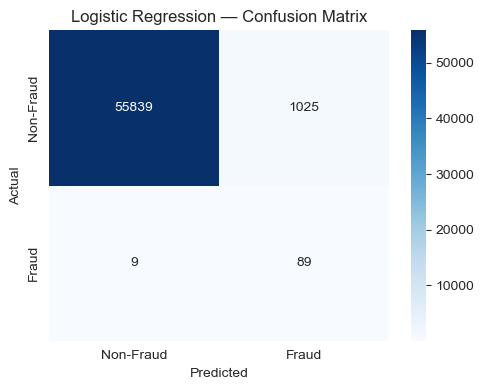

=== Random Forest ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.83      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9583


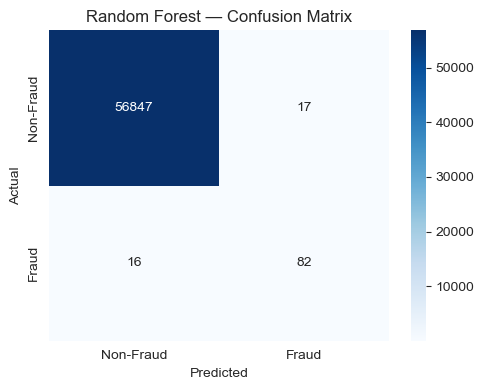

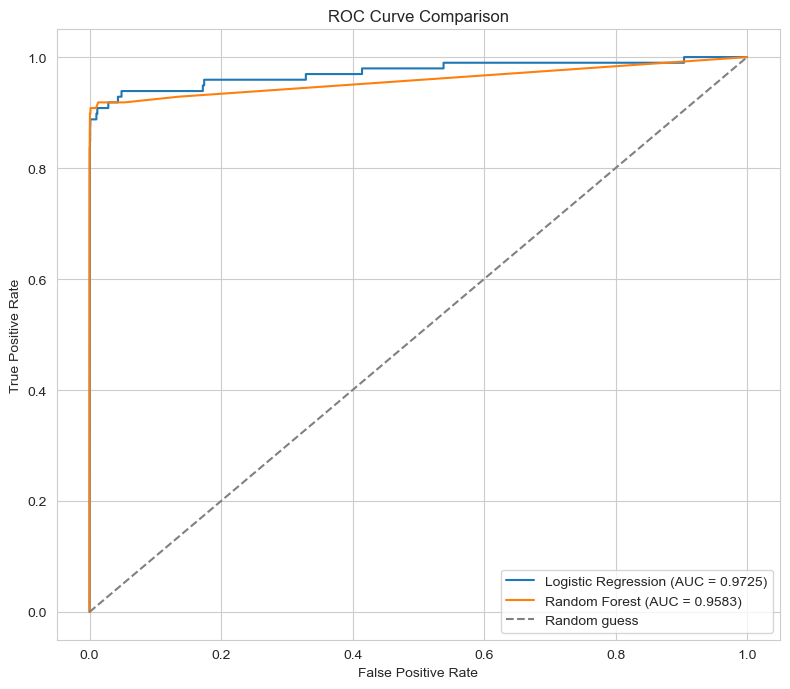

In [11]:
#Evaluation — Precision, Recall, F1, AUC-ROC

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, y_true, y_pred, y_probs):
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud']))
    auc = roc_auc_score(y_true, y_probs)
    print(f"AUC-ROC: {auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'])
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return auc

lr_auc = evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)
rf_auc = evaluate_model("Random Forest", y_test, rf_preds, rf_probs)

# ROC curve comparison
plt.figure(figsize=(8,7))
for name, probs in [("Logistic Regression", lr_probs), ("Random Forest", rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

Model Comparison: The two models produced dramatically different tradeoffs. Logistic Regression achieved higher recall (91% vs. 84%) — catching slightly more actual fraud cases (89 vs. 82 out of 98) — but at a severe precision cost: only 8% of its fraud flags were correct (1,025 false positives against just 89 true positives). Random Forest achieved far higher precision (83% vs. 8%) with only a modest recall trade-off (84% vs. 91%), producing just 17 false positives while still catching 82 of 98 fraud cases, and a dramatically better F1-score for the fraud class (0.83 vs. 0.15).

Notably, Logistic Regression actually has the higher AUC-ROC (0.9725 vs. 0.9583) — at first glance this seems to contradict Random Forest being the better model, but it isn't a contradiction. AUC-ROC measures ranking quality across all possible classification thresholds, while the precision/recall/F1 numbers above reflect performance at the single default threshold (0.5) each model actually used to make its predictions. Logistic Regression's probability estimates are well-ranked overall, but its default threshold of 0.5 turned out poorly calibrated for this severely imbalanced problem — likely because SMOTE's synthetic 50/50 training balance shifted where the model's natural decision boundary sits, making it "trigger-happy" about calling things fraud at the standard threshold. Random Forest's ensemble of decision trees produced predictions that were better calibrated to real-world class proportions at that same default threshold, even though its ROC curve is slightly less optimal in the abstract.

Practical conclusion: Random Forest is the clearly better model for actual deployment as-is. A fraud system generating 1,025 false alarms to catch 89 real fraud cases (Logistic Regression) would overwhelm any human review team and likely get ignored or disabled — while Random Forest's 17 false alarms for 82 caught cases is a far more operationally usable ratio. This is a good example of why AUC-ROC alone shouldn't be the deciding metric — it's most useful for comparing a model's ranking ability, not necessarily its out-of-the-box, real-world usability at a specific decision threshold. (A worthwhile follow-up, if you want to extend this further, would be tuning Logistic Regression's classification threshold above 0.5 to see if its recall advantage could be preserved while reducing false positives closer to Random Forest's level.)

   Feature  Importance
13     V14        0.23
3       V4        0.14
9      V10        0.11
16     V17        0.09
2       V3        0.07
11     V12        0.06
10     V11        0.06
15     V16        0.04
1       V2        0.03
28  Amount        0.02
6       V7        0.02
8       V9        0.01
20     V21        0.01
26     V27        0.01
7       V8        0.01


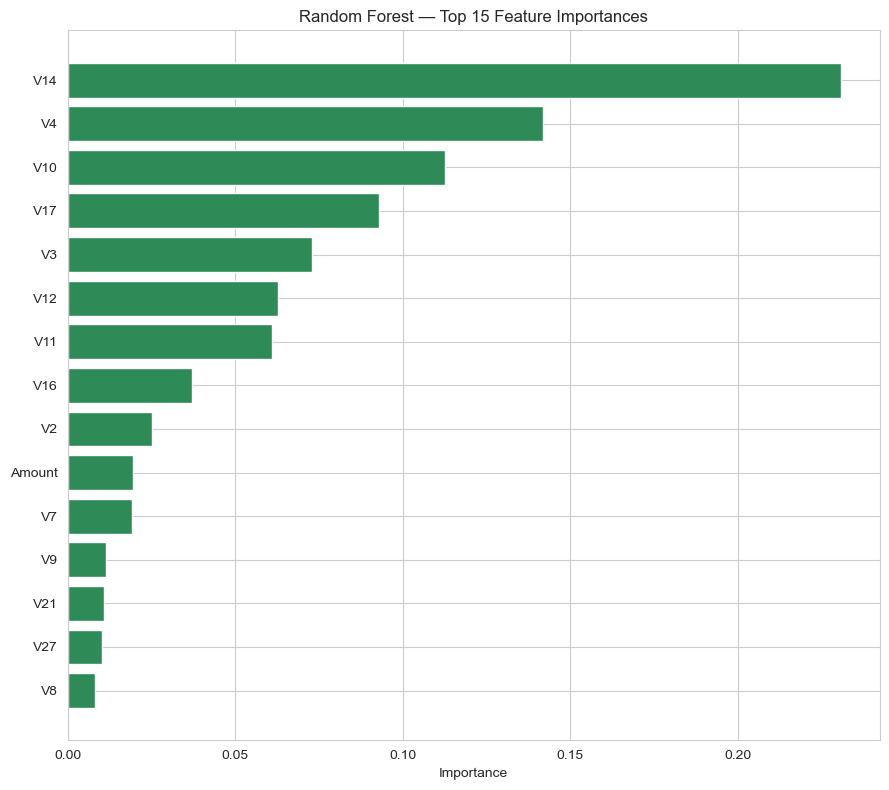

In [14]:
# --- Random Forest feature importance ---
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.head(15))

plt.figure(figsize=(9,8))
top_features = rf_importance.head(15)
bars = plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='seagreen')
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

   Feature  Coefficient
27     V28         1.27
0       V1         1.17
3       V4         1.11
4       V5         0.93
10     V11         0.83
2       V3         0.68
21     V22         0.66
1       V2         0.63
22     V23         0.61
18     V19         0.23
24     V25         0.23
20     V21         0.18
29    Hour         0.03
28  Amount         0.01
14     V15        -0.04
25     V26        -0.20
23     V24        -0.22
12     V13        -0.37
17     V18        -0.47
7       V8        -0.57
5       V6        -0.66
26     V27        -0.79
8       V9        -0.91
6       V7        -1.03
15     V16        -1.26
16     V17        -1.46
11     V12        -1.51
19     V20        -1.60
9      V10        -1.66
13     V14        -1.80


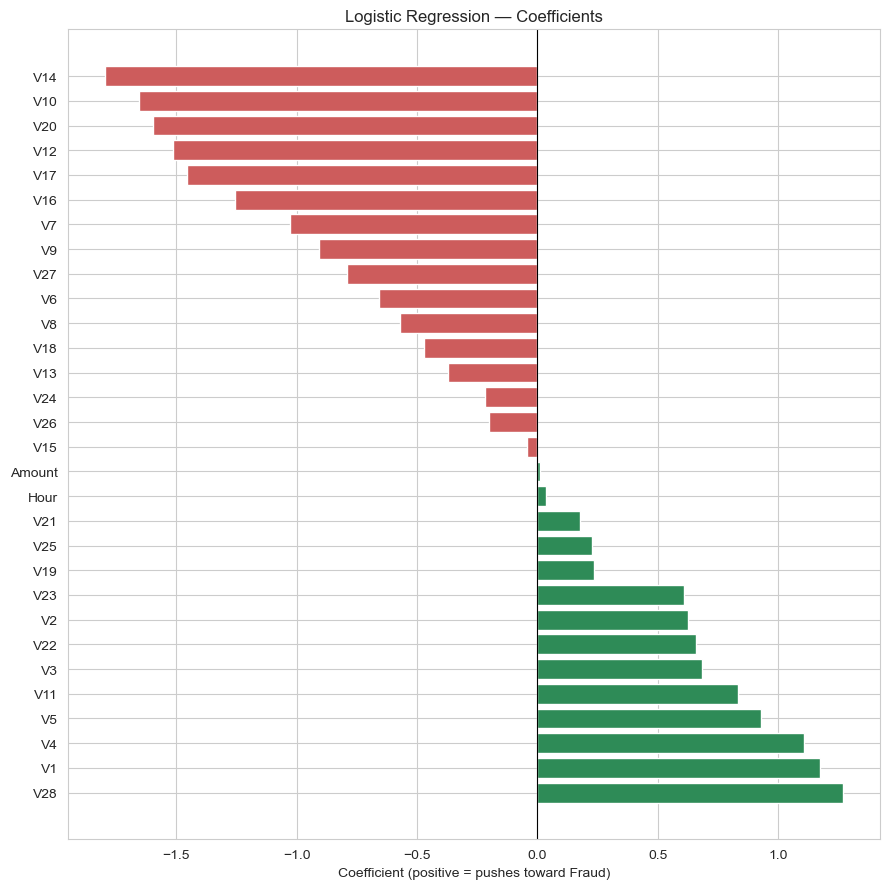

In [15]:
# --- Logistic Regression coefficients ---
lr_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(lr_coef)

plt.figure(figsize=(9,9))
colors = ['seagreen' if c > 0 else 'indianred' for c in lr_coef['Coefficient']]
bars = plt.barh(lr_coef['Feature'], lr_coef['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Logistic Regression — Coefficients")
plt.xlabel("Coefficient (positive = pushes toward Fraud)")
plt.tight_layout()
plt.show()

Feature Importance Analysis: Both models independently identify V14 as a top predictor — it's the single most important feature in Random Forest (importance 0.23, roughly 1.6x the next-highest feature) and has the largest-magnitude coefficient in Logistic Regression (-1.80). V10, V4, V12, and V17 also rank highly in both models, giving strong convergent evidence that these specific PCA components genuinely capture real fraud-distinguishing patterns, rather than being an artifact of one particular algorithm.

One notable difference in direction: Logistic Regression's largest-magnitude coefficients (V14, V10, V20, V12, V17) are all negative — meaning lower values of these components push toward fraud, while Random Forest doesn't preserve directionality at all (importance is always positive, since it just measures how useful a split on that feature was). This is a useful reminder that the two techniques answer related but different questions: Random Forest importance tells you how much a feature matters for making correct splits, while Logistic Regression coefficients tell you which direction a feature pushes the prediction — both are valid, but not directly comparable in magnitude.

Our two engineered/original features — Hour and Amount — ranked low in both models (Amount: 0.02 importance / +0.01 coefficient; Hour: not in RF's top 15 / +0.03 coefficient, both near-zero). This is a meaningful finding on its own: despite the clear, striking hour-of-day pattern found in the earlier EDA (fraud disproportionately spiking at 2 AM and 11 AM), Hour provided almost no standalone predictive value once the anonymized V1–V28 features were available. This suggests the PCA-derived features likely already encode whatever underlying signal correlates with time-of-day (e.g. transaction context that happens to cluster at certain hours), making the explicit Hour feature largely redundant rather than independently useful. This is a good example of why a feature can be a real, statistically valid pattern in EDA while still not surviving as valuable once more powerful features are already in the model — an important nuance to note rather than overstating the earlier time-of-day finding as necessarily "predictive."

## Scalability: Handling 1 Million Transactions Per Hour

Processing 1 million transactions/hour (~278 transactions/second) at production scale raises different considerations than this notebook's offline analysis:

**Inference speed:** Random Forest predictions are fast at inference time (a trained forest just runs each transaction through ~100 decision trees), easily capable of sub-millisecond predictions per transaction on modest hardware — 278/second is well within reach of a single machine, and trivially parallelizable across multiple servers if needed.

**Retraining cadence:** Fraud patterns evolve as fraudsters adapt to detection systems, so the model would need periodic retraining (e.g. daily or weekly) on fresh data rather than being trained once and deployed indefinitely — a static model's accuracy would degrade over time as new fraud tactics emerge that don't match the patterns it originally learned.

**Feature computation pipeline:** In this notebook, features (V1-V28) were already pre-computed via PCA. In a real production system, features would need to be computed in real-time as each transaction arrives — this requires a low-latency feature pipeline (e.g. streaming infrastructure like Kafka + a feature store), not just a trained model sitting in isolation.

**Class imbalance at scale:** SMOTE (used here) doesn't scale well to millions of rows, since it requires computing nearest neighbors across the full minority class for oversampling — at production scale, `class_weight='balanced'` (adjusting the loss function directly rather than generating synthetic samples) is typically more practical, since it avoids the memory and computation cost of generating and storing synthetic training examples.